# Gradient Normalization: Building Strong Intuitions

**Learning Objectives:**
- Understand gradient explosion and vanishing problems
- Learn how gradient norm clipping works mathematically
- Compare different normalization strategies
- Build intuition about when to use gradient normalization
- Conduct hands-on experiments to see the effects

---

## Part 1: Introduction & Setup

Gradient normalization is a crucial technique in deep learning that helps stabilize training. In this notebook, we'll build a deep understanding of:
- **What** gradient problems are
- **Why** they occur
- **How** gradient normalization solves them
- **When** to use it (and when not to)

In [ ]:
# Import dependencies

# Import shared utilities

# Enable autoreload
%load_ext autoreload
%autoreload 2

# Set seed for reproducibility
set_seed(42)

# Device setup
device = get_device()

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Part 2: The Gradient Problem - An Intuitive Introduction

### What are gradient problems?

When training deep neural networks, we use backpropagation to compute gradients. These gradients tell us how to update our parameters. But sometimes, these gradients can:

1. **Explode**: Become extremely large (e.g., 10¹⁰ or inf)
2. **Vanish**: Become extremely small (e.g., 10⁻¹⁰ or 0)

Both problems prevent effective learning!

### Why do gradient problems occur?

Think of backpropagation as passing a message through many layers. Each layer multiplies the gradient by its local derivative. With many layers:
- If derivatives > 1: gradients grow exponentially → **explosion**
- If derivatives < 1: gradients shrink exponentially → **vanishing**

Let's visualize this!

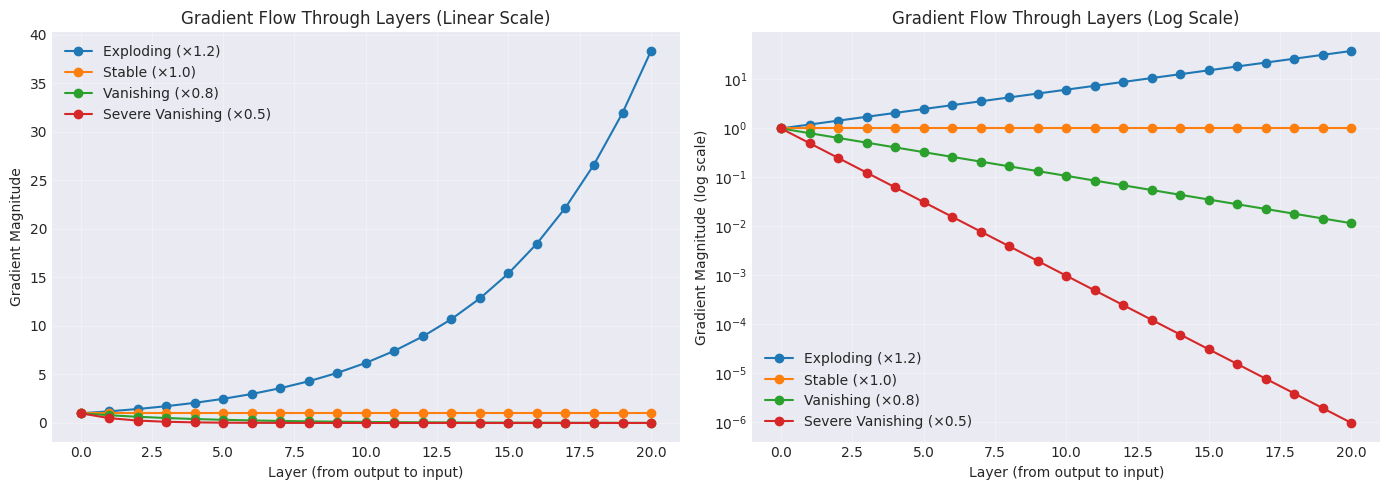


🤔 Reflection: What happens to the gradients in early layers when multiplier > 1? When multiplier < 1?


In [2]:
def simulate_gradient_propagation(num_layers, weight_multiplier):
    """Simulate gradient flow through layers with constant weight multiplier."""
    gradients = [1.0]  # Start with gradient of 1
    
    for layer in range(num_layers):
        # Each layer multiplies the gradient
        gradients.append(gradients[-1] * weight_multiplier)
    
    return gradients

# Simulate different scenarios
num_layers = 20
scenarios = {
    'Exploding (×1.2)': 1.2,
    'Stable (×1.0)': 1.0,
    'Vanishing (×0.8)': 0.8,
    'Severe Vanishing (×0.5)': 0.5
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Linear scale
for label, multiplier in scenarios.items():
    grads = simulate_gradient_propagation(num_layers, multiplier)
    ax1.plot(range(len(grads)), grads, marker='o', label=label)

ax1.set_xlabel('Layer (from output to input)')
ax1.set_ylabel('Gradient Magnitude')
ax1.set_title('Gradient Flow Through Layers (Linear Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Log scale (better for seeing vanishing)
for label, multiplier in scenarios.items():
    grads = simulate_gradient_propagation(num_layers, multiplier)
    ax2.semilogy(range(len(grads)), grads, marker='o', label=label)

ax2.set_xlabel('Layer (from output to input)')
ax2.set_ylabel('Gradient Magnitude (log scale)')
ax2.set_title('Gradient Flow Through Layers (Log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🤔 Reflection: What happens to the gradients in early layers when multiplier > 1? When multiplier < 1?")

### Key Insight

With 20 layers:
- **Exploding**: 1.2²⁰ ≈ 38.3 (gradient magnified 38×)
- **Vanishing**: 0.8²⁰ ≈ 0.012 (gradient shrunk to 1%)

This is why deep networks are hard to train! Now let's see this in real networks.

## Part 3: Real Gradient Explosion in Neural Networks

Let's create a deep network and watch gradients explode during training.

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

In [3]:
class DeepNetwork(nn.Module):
    """A deep network designed to demonstrate gradient issues."""
    
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super().__init__()
        self.num_layers = num_layers
        
        # Input layer
        self.layers = nn.ModuleList([nn.Linear(input_size, hidden_size)])
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_size, hidden_size))
        
        # Output layer
        self.layers.append(nn.Linear(hidden_size, output_size))
    
    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = torch.tanh(layer(x))  # tanh activation
        x = self.layers[-1](x)  # No activation on output
        return x

# Create a simple synthetic dataset
def create_synthetic_data(n_samples=1000, input_dim=10, output_dim=2):
    """Create synthetic classification data."""
    X = torch.randn(n_samples, input_dim)
    # Simple linear relationship with noise
    y = (X.sum(dim=1, keepdim=True) > 0).long()
    return TensorDataset(X, y.squeeze())

# Create dataset
train_dataset = create_synthetic_data(n_samples=800)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"✓ Created synthetic dataset with {len(train_dataset)} samples")
print(f"✓ Input dimension: 10, Output classes: 2")

✓ Created synthetic dataset with 800 samples
✓ Input dimension: 10, Output classes: 2


### Computing Gradient Norms

Before we train, let's understand how to compute gradient norms. The **gradient norm** is the magnitude of all gradients, typically measured as the L2 norm:

$$\text{grad\_norm} = \sqrt{\sum_{i=1}^{n} g_i^2}$$

where $g_i$ are individual gradient values across all parameters.

In [4]:
def compute_gradient_norm(model):
    """Compute the L2 norm of all gradients in the model."""
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)  # L2 norm
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5
    return total_norm

def compute_gradient_norms_per_layer(model):
    """Compute gradient norms for each layer separately."""
    layer_norms = []
    for name, p in model.named_parameters():
        if p.grad is not None:
            layer_norms.append((name, p.grad.data.norm(2).item()))
    return layer_norms

# Test on a simple example
test_model = DeepNetwork(10, 20, 2, num_layers=5).to(device)
test_input = torch.randn(4, 10).to(device)
test_target = torch.randint(0, 2, (4,)).to(device)

# Forward and backward pass
output = test_model(test_input)
loss = F.cross_entropy(output, test_target)
loss.backward()

# Compute gradient norm
grad_norm = compute_gradient_norm(test_model)
print(f"\nTotal gradient norm: {grad_norm:.4f}")

print("\nGradient norms per layer:")
for name, norm in compute_gradient_norms_per_layer(test_model):
    print(f"  {name:20s}: {norm:.4f}")


Total gradient norm: 0.4002

Gradient norms per layer:
  layers.0.weight     : 0.0970
  layers.0.bias       : 0.0136
  layers.1.weight     : 0.1537
  layers.1.bias       : 0.0154
  layers.2.weight     : 0.2348
  layers.2.bias       : 0.0278
  layers.3.weight     : 0.1885
  layers.3.bias       : 0.0442
  layers.4.weight     : 0.1684
  layers.4.bias       : 0.0703


## Part 4: Training Without Gradient Clipping - Observing Explosion

Now let's train a deep network and watch what happens to gradients.

In [ ]:
from collections import defaultdict

In [5]:
def train_model(model, train_loader, num_epochs, learning_rate, 
                clip_value=None, verbose=True):
    """Train model and track gradient statistics."""
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    # Track statistics
    history = {
        'loss': [],
        'grad_norm': [],
        'grad_norm_per_layer': defaultdict(list)
    }
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_grad_norms = []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            output = model(batch_x)
            loss = F.cross_entropy(output, batch_y)
            
            # Backward pass
            loss.backward()
            
            # Compute gradient norm BEFORE clipping
            grad_norm = compute_gradient_norm(model)
            epoch_grad_norms.append(grad_norm)
            
            # Gradient clipping (if specified)
            if clip_value is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            
            # Update parameters
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Record statistics
        avg_loss = epoch_loss / len(train_loader)
        avg_grad_norm = np.mean(epoch_grad_norms)
        
        history['loss'].append(avg_loss)
        history['grad_norm'].append(avg_grad_norm)
        
        if verbose and (epoch % 10 == 0 or epoch == num_epochs - 1):
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Grad Norm: {avg_grad_norm:.2f}")
    
    return history

# Create a deep network (prone to gradient issues)
print("Training deep network WITHOUT gradient clipping...\n")
model_no_clip = DeepNetwork(input_size=10, hidden_size=64, output_size=2, num_layers=10)
history_no_clip = train_model(model_no_clip, train_loader, num_epochs=50, 
                               learning_rate=0.1, clip_value=None)

Training deep network WITHOUT gradient clipping...

Epoch   0 | Loss: 0.6941 | Grad Norm: 0.12


Epoch  10 | Loss: 0.0552 | Grad Norm: 1.05


Epoch  20 | Loss: 0.0177 | Grad Norm: 0.55


Epoch  30 | Loss: 0.0178 | Grad Norm: 0.62


Epoch  40 | Loss: 0.0050 | Grad Norm: 0.23


Epoch  49 | Loss: 0.0005 | Grad Norm: 0.02


Visualize the results with multiple plots for comparison.

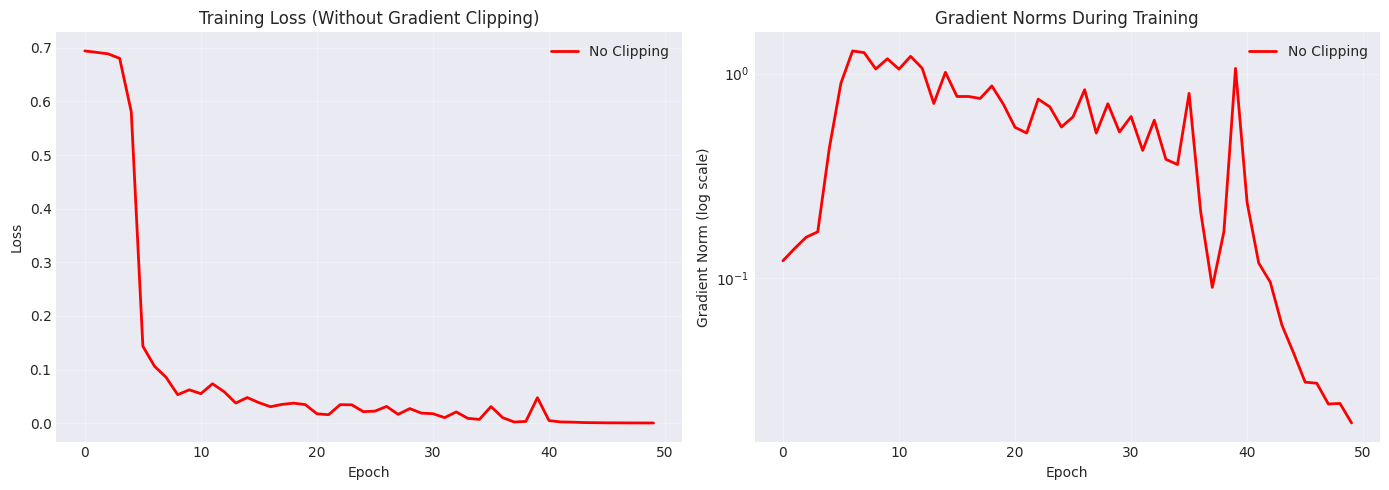


📊 Gradient Statistics:
   Min gradient norm: 0.02
   Max gradient norm: 1.29
   Mean gradient norm: 0.55

🤔 Reflection: Are the gradients stable? What do you notice about the loss curve?


In [6]:
# Visualize training dynamics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history_no_clip['loss'], linewidth=2, color='red', label='No Clipping')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (Without Gradient Clipping)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot gradient norms (log scale)
ax2.semilogy(history_no_clip['grad_norm'], linewidth=2, color='red', label='No Clipping')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Gradient Norm (log scale)')
ax2.set_title('Gradient Norms During Training')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Gradient Statistics:")
print(f"   Min gradient norm: {min(history_no_clip['grad_norm']):.2f}")
print(f"   Max gradient norm: {max(history_no_clip['grad_norm']):.2f}")
print(f"   Mean gradient norm: {np.mean(history_no_clip['grad_norm']):.2f}")
print("\n🤔 Reflection: Are the gradients stable? What do you notice about the loss curve?")

## Part 5: Understanding Gradient Norm Clipping - The Math

### What is Gradient Clipping?

Gradient clipping prevents gradients from becoming too large by scaling them down if their norm exceeds a threshold.

### The Algorithm

Given:
- Gradients $\mathbf{g} = [g_1, g_2, ..., g_n]$
- Maximum allowed norm $\text{max\_norm}$

**Step 1**: Compute total gradient norm
$$\|\mathbf{g}\| = \sqrt{\sum_{i=1}^{n} g_i^2}$$

**Step 2**: If $\|\mathbf{g}\| > \text{max\_norm}$, scale gradients:
$$\mathbf{g}_{\text{clipped}} = \mathbf{g} \cdot \frac{\text{max\_norm}}{\|\mathbf{g}\|}$$

**Key Insight**: Clipping preserves the **direction** of gradients while limiting their **magnitude**!

In [7]:
def manual_gradient_clip(gradients, max_norm):
    """Manually implement gradient clipping to understand the algorithm."""
    # Step 1: Compute gradient norm
    grad_norm = torch.sqrt(sum(g.pow(2).sum() for g in gradients))
    
    # Step 2: Compute scaling factor
    clip_coef = max_norm / (grad_norm + 1e-6)
    
    # Step 3: Clip if necessary (clip_coef < 1 means norm > max_norm)
    clip_coef_clamped = min(clip_coef.item(), 1.0)
    
    # Step 4: Scale gradients
    clipped_gradients = [g * clip_coef_clamped for g in gradients]
    
    return clipped_gradients, grad_norm.item(), clip_coef_clamped

# Demonstration with toy gradients
print("🧪 Gradient Clipping Demonstration\n")

# Create some toy gradients
toy_gradients = [
    torch.tensor([3.0, 4.0]),     # norm = 5.0
    torch.tensor([1.0, 2.0, 2.0]) # norm = 3.0
]

# Original norm
original_norm = torch.sqrt(sum(g.pow(2).sum() for g in toy_gradients)).item()
print(f"Original gradient norm: {original_norm:.4f}")

# Test different max_norm values
for max_norm in [10.0, 5.0, 2.0]:
    clipped, norm, coef = manual_gradient_clip(toy_gradients, max_norm)
    clipped_norm = torch.sqrt(sum(g.pow(2).sum() for g in clipped)).item()
    
    print(f"\nmax_norm = {max_norm}")
    print(f"  Scaling coefficient: {coef:.4f}")
    print(f"  Clipped gradient norm: {clipped_norm:.4f}")
    print(f"  Clipped? {coef < 1.0}")

print("\n💡 Key Insight: Clipping only activates when gradient norm exceeds max_norm!")

🧪 Gradient Clipping Demonstration

Original gradient norm: 5.8310

max_norm = 10.0
  Scaling coefficient: 1.0000
  Clipped gradient norm: 5.8310
  Clipped? False

max_norm = 5.0
  Scaling coefficient: 0.8575
  Clipped gradient norm: 5.0000
  Clipped? True

max_norm = 2.0
  Scaling coefficient: 0.3430
  Clipped gradient norm: 2.0000
  Clipped? True

💡 Key Insight: Clipping only activates when gradient norm exceeds max_norm!


### Visualizing Gradient Clipping

Let's visualize how clipping affects gradient vectors.

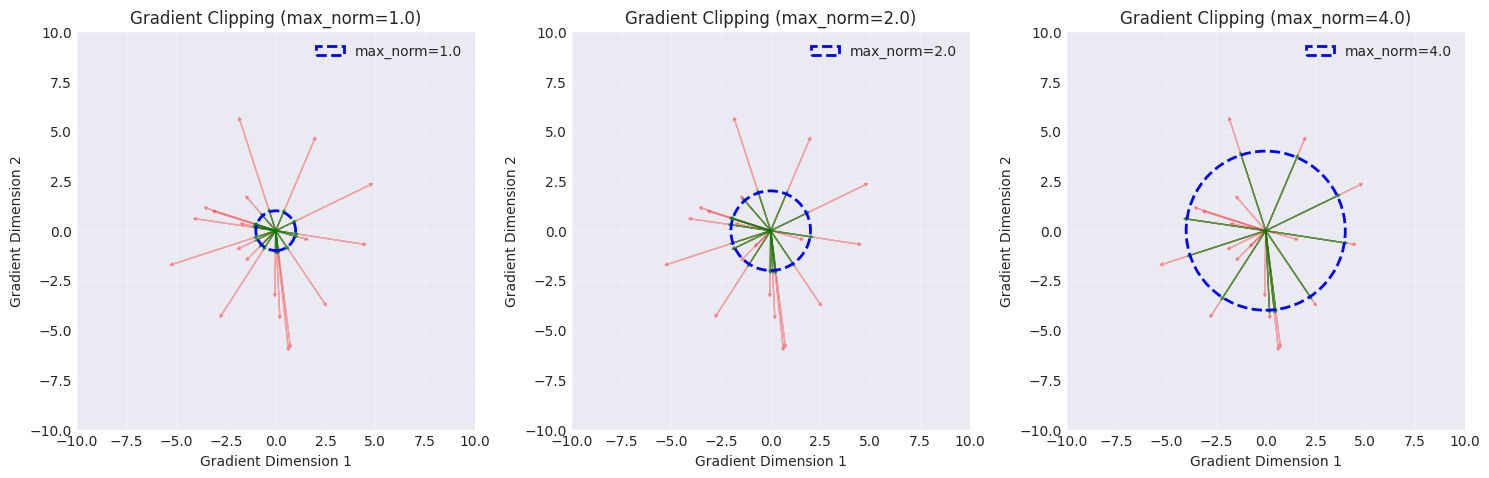


🎯 Key Observation: Gradients outside the circle are scaled to lie on the circle.
   Their direction is preserved, but magnitude is limited!


In [8]:
def visualize_clipping_2d():
    """Visualize gradient clipping in 2D space."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Generate random gradient vectors
    np.random.seed(42)
    n_vectors = 20
    gradients = np.random.randn(n_vectors, 2) * 3  # Random gradients
    
    max_norms = [1.0, 2.0, 4.0]
    
    for ax, max_norm in zip(axes, max_norms):
        # Plot original gradients
        for g in gradients:
            ax.arrow(0, 0, g[0], g[1], head_width=0.15, head_length=0.15,
                    fc='red', ec='red', alpha=0.3, label='Original' if g is gradients[0] else '')
        
        # Plot clipped gradients
        for g in gradients:
            norm = np.linalg.norm(g)
            if norm > max_norm:
                g_clipped = g * (max_norm / norm)
                ax.arrow(0, 0, g_clipped[0], g_clipped[1], head_width=0.15, head_length=0.15,
                        fc='green', ec='green', alpha=0.6, 
                        label='Clipped' if g is gradients[0] else '')
        
        # Draw clipping circle
        circle = plt.Circle((0, 0), max_norm, color='blue', fill=False, 
                           linestyle='--', linewidth=2, label=f'max_norm={max_norm}')
        ax.add_patch(circle)
        
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(f'Gradient Clipping (max_norm={max_norm})')
        ax.set_xlabel('Gradient Dimension 1')
        ax.set_ylabel('Gradient Dimension 2')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

visualize_clipping_2d()
print("\n🎯 Key Observation: Gradients outside the circle are scaled to lie on the circle.")
print("   Their direction is preserved, but magnitude is limited!")

## Part 6: Training WITH Gradient Clipping - The Difference

Now let's train the same network with gradient clipping and compare.

In [ ]:
from aiml_notebooks import get_device, set_seed, create_dataset, create_dataloaders

In [9]:
# Reset seed for fair comparison
set_seed(42)

print("Training deep network WITH gradient clipping...\n")
model_with_clip = DeepNetwork(input_size=10, hidden_size=64, output_size=2, num_layers=10)
history_with_clip = train_model(model_with_clip, train_loader, num_epochs=50, 
                                learning_rate=0.1, clip_value=1.0)

Training deep network WITH gradient clipping...

Epoch   0 | Loss: 0.6936 | Grad Norm: 0.17


Epoch  10 | Loss: 0.0464 | Grad Norm: 1.34


Epoch  20 | Loss: 0.0286 | Grad Norm: 1.03


Epoch  30 | Loss: 0.0137 | Grad Norm: 0.44


Epoch  40 | Loss: 0.0080 | Grad Norm: 0.24


Epoch  49 | Loss: 0.0002 | Grad Norm: 0.01


Visualize the results with multiple plots for comparison.

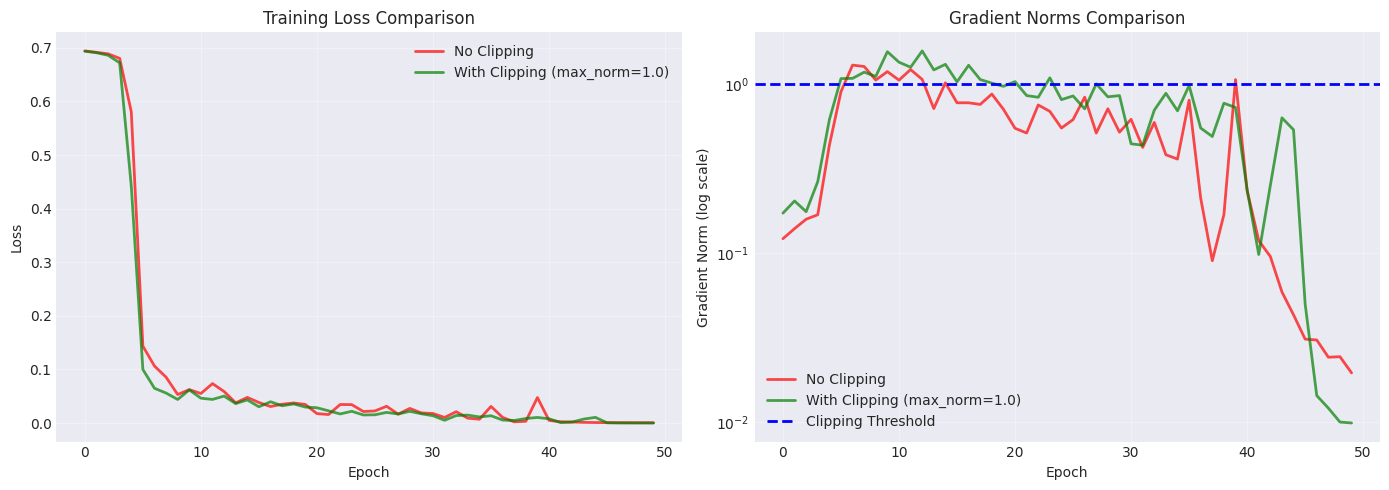


📊 Comparison Summary:

Without Clipping:
   Final loss: 0.0005
   Max gradient norm: 1.29
   Training stability: Stable

With Clipping:
   Final loss: 0.0002
   Max gradient norm: 1.57
   Training stability: STABLE

🤔 Reflection: How does gradient clipping affect training stability and convergence?


In [10]:
# Compare training dynamics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss comparison
ax1.plot(history_no_clip['loss'], linewidth=2, color='red', 
         label='No Clipping', alpha=0.7)
ax1.plot(history_with_clip['loss'], linewidth=2, color='green', 
         label='With Clipping (max_norm=1.0)', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot gradient norms comparison (log scale)
ax2.semilogy(history_no_clip['grad_norm'], linewidth=2, color='red', 
             label='No Clipping', alpha=0.7)
ax2.semilogy(history_with_clip['grad_norm'], linewidth=2, color='green', 
             label='With Clipping (max_norm=1.0)', alpha=0.7)
ax2.axhline(y=1.0, color='blue', linestyle='--', linewidth=2, 
            label='Clipping Threshold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Gradient Norm (log scale)')
ax2.set_title('Gradient Norms Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Comparison Summary:")
print("\nWithout Clipping:")
print(f"   Final loss: {history_no_clip['loss'][-1]:.4f}")
print(f"   Max gradient norm: {max(history_no_clip['grad_norm']):.2f}")
print(f"   Training stability: {'UNSTABLE' if max(history_no_clip['grad_norm']) > 100 else 'Stable'}")

print("\nWith Clipping:")
print(f"   Final loss: {history_with_clip['loss'][-1]:.4f}")
print(f"   Max gradient norm: {max(history_with_clip['grad_norm']):.2f}")
print(f"   Training stability: STABLE")

print("\n🤔 Reflection: How does gradient clipping affect training stability and convergence?")

## Part 7: Finding the Right Clipping Threshold

The `max_norm` hyperparameter is crucial. Let's experiment with different values.

In [11]:
# Test different clipping thresholds
clip_values = [0.1, 0.5, 1.0, 5.0, 10.0, None]  # None = no clipping
histories = {}

print("Training with different clipping thresholds...\n")
for clip_val in clip_values:
    set_seed(42)  # Same initialization for fair comparison
    model = DeepNetwork(input_size=10, hidden_size=64, output_size=2, num_layers=10)
    
    label = f"max_norm={clip_val}" if clip_val is not None else "No Clipping"
    print(f"Training with {label}...")
    
    history = train_model(model, train_loader, num_epochs=50, 
                         learning_rate=0.1, clip_value=clip_val, verbose=False)
    histories[label] = history

print("\n✓ Training complete!")

Training with different clipping thresholds...

Training with max_norm=0.1...


Training with max_norm=0.5...


Training with max_norm=1.0...


Training with max_norm=5.0...


Training with max_norm=10.0...


Training with No Clipping...



✓ Training complete!


Visualize the results with multiple plots for comparison.

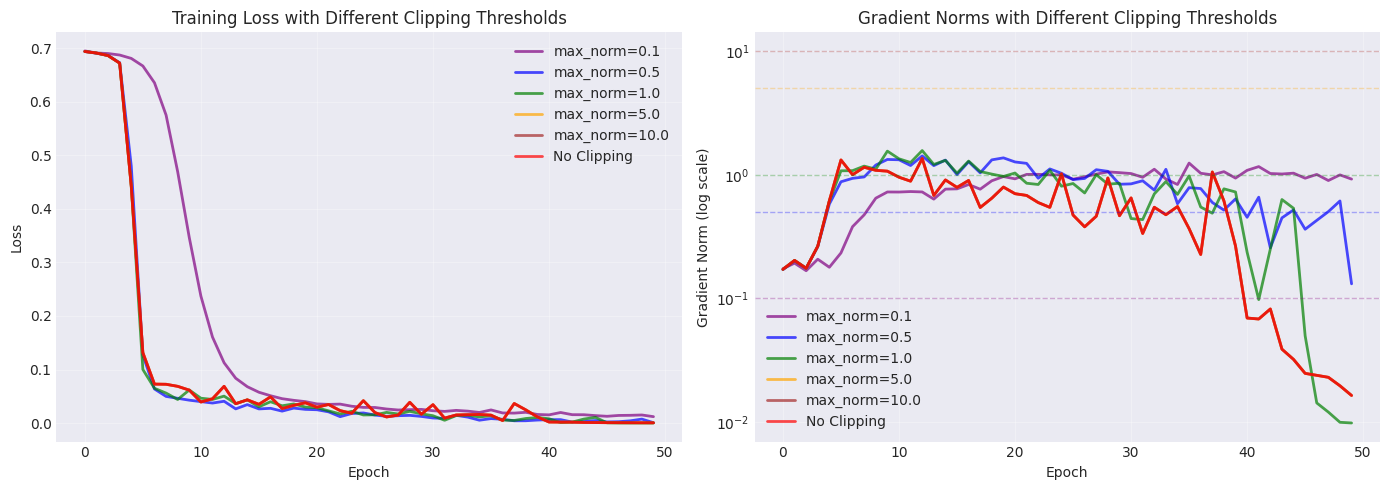


📊 Performance Summary:

Threshold            Final Loss      Max Grad Norm   Converged?
-----------------------------------------------------------------
max_norm=0.1         0.0120          1.24            ✓
max_norm=0.5         0.0007          1.42            ✓
max_norm=1.0         0.0002          1.57            ✓
max_norm=5.0         0.0005          1.35            ✓
max_norm=10.0        0.0005          1.35            ✓
No Clipping          0.0005          1.35            ✓

🤔 Reflection: What threshold seems to work best? Too small? Too large?


In [12]:
# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['purple', 'blue', 'green', 'orange', 'brown', 'red']

# Plot losses
for (label, history), color in zip(histories.items(), colors):
    ax1.plot(history['loss'], linewidth=2, label=label, color=color, alpha=0.7)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss with Different Clipping Thresholds')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot gradient norms
for (label, history), color in zip(histories.items(), colors):
    ax2.semilogy(history['grad_norm'], linewidth=2, label=label, color=color, alpha=0.7)

# Add threshold lines
for clip_val, color in zip([0.1, 0.5, 1.0, 5.0, 10.0], colors):
    ax2.axhline(y=clip_val, color=color, linestyle='--', linewidth=1, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Gradient Norm (log scale)')
ax2.set_title('Gradient Norms with Different Clipping Thresholds')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n📊 Performance Summary:\n")
print(f"{'Threshold':<20} {'Final Loss':<15} {'Max Grad Norm':<15} {'Converged?'}")
print("-" * 65)

for label, history in histories.items():
    final_loss = history['loss'][-1]
    max_grad = max(history['grad_norm'])
    converged = "✓" if final_loss < 0.6 else "✗"
    print(f"{label:<20} {final_loss:<15.4f} {max_grad:<15.2f} {converged}")

print("\n🤔 Reflection: What threshold seems to work best? Too small? Too large?")

### Guidelines for Choosing max_norm

Based on our experiments:

1. **Too Small (0.1-0.5)**: 
   - Over-restricts gradients
   - Slower convergence
   - May prevent learning

2. **Just Right (1.0-5.0)**:
   - Stabilizes training
   - Allows sufficient gradient flow
   - Good balance

3. **Too Large (10.0+)**:
   - Rarely clips
   - Minimal effect
   - May not prevent explosion

**Rule of Thumb**: Start with `max_norm=1.0` and adjust based on gradient statistics.

## Part 8: Global Norm vs Per-Parameter Clipping

There are two main clipping strategies:

1. **Global Norm Clipping** (what we've been using)
   - Compute norm across ALL parameters
   - Scale all gradients by the same factor
   - Preserves relative gradient magnitudes between layers

2. **Per-Parameter Clipping**
   - Clip each parameter's gradient independently
   - Different scaling for each parameter
   - Can distort relative magnitudes

In [13]:
def clip_grad_norm_global(parameters, max_norm):
    """Global norm clipping (PyTorch default)."""
    return torch.nn.utils.clip_grad_norm_(parameters, max_norm)

def clip_grad_value_per_param(parameters, clip_value):
    """Per-parameter clipping (clips each gradient element)."""
    return torch.nn.utils.clip_grad_value_(parameters, clip_value)

# Demonstrate the difference
print("🧪 Comparing Clipping Strategies\n")

# Create a model and compute gradients
demo_model = DeepNetwork(10, 20, 2, num_layers=5).to(device)
demo_input = torch.randn(4, 10).to(device)
demo_target = torch.randint(0, 2, (4,)).to(device)

# Forward and backward
output = demo_model(demo_input)
loss = F.cross_entropy(output, demo_target)
loss.backward()

# Store original gradients
original_grads = {name: p.grad.clone() for name, p in demo_model.named_parameters() if p.grad is not None}
original_norm = compute_gradient_norm(demo_model)

print(f"Original gradient norm: {original_norm:.4f}\n")

# Test global clipping
for name, p in demo_model.named_parameters():
    if p.grad is not None:
        p.grad = original_grads[name].clone()

global_norm = clip_grad_norm_global(demo_model.parameters(), max_norm=1.0)
print(f"After global norm clipping (max_norm=1.0):")
print(f"  New gradient norm: {compute_gradient_norm(demo_model):.4f}")
print(f"  Clipped: {global_norm > 1.0}\n")

# Test per-parameter clipping
for name, p in demo_model.named_parameters():
    if p.grad is not None:
        p.grad = original_grads[name].clone()

clip_grad_value_per_param(demo_model.parameters(), clip_value=0.1)
print(f"After per-parameter clipping (clip_value=0.1):")
print(f"  New gradient norm: {compute_gradient_norm(demo_model):.4f}")

print("\n💡 Key Difference:")
print("   Global clipping: Scales all gradients proportionally")
print("   Per-parameter clipping: Clips each gradient independently")

🧪 Comparing Clipping Strategies

Original gradient norm: 1.1034

After global norm clipping (max_norm=1.0):
  New gradient norm: 1.0000
  Clipped: True

After per-parameter clipping (clip_value=0.1):
  New gradient norm: 0.7101

💡 Key Difference:
   Global clipping: Scales all gradients proportionally
   Per-parameter clipping: Clips each gradient independently


### When to Use Each Strategy?

**Global Norm Clipping (Recommended)**:
- ✅ Preserves gradient relationships between layers
- ✅ More principled mathematically
- ✅ Standard in deep learning (RNNs, Transformers)
- Use: Most scenarios, especially deep networks

**Per-Parameter Clipping**:
- ✅ Simpler implementation
- ✅ Can help with individual parameter outliers
- ⚠️ May distort gradient relationships
- Use: Simple networks, when you have parameter-specific issues

## Part 9: Gradient Clipping in Practice - Real-World Example

Let's apply gradient clipping to a more realistic task: name generation with a recurrent network.

In [14]:
# Load names dataset
full_dataset, train_dataset, val_dataset = create_dataset(
    dataset_id="names",
    splits=[0.9, 0.1]
)

# Extract tokenizer
tokenizer = full_dataset.tokenizer

# Create data loaders
train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=128
)

print(f"✓ Loaded names dataset")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Vocabulary size: {tokenizer.vocab_size}")

✓ Loaded names dataset
  Training samples: 28829
  Validation samples: 3204
  Vocabulary size: 27


Define the CharRNN architecture.

In [15]:
class CharRNN(nn.Module):
    """Character-level RNN for name generation."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, hidden=None):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        output, hidden = self.rnn(embedded, hidden)  # (batch, seq_len, hidden_dim)
        output = self.fc(output)  # (batch, seq_len, vocab_size)
        return output, hidden

# Create model
model_rnn = CharRNN(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=32,
    hidden_dim=128,
    num_layers=3  # Deep RNN - prone to gradient issues
).to(device)

print(f"\n✓ Created CharRNN with {sum(p.numel() for p in model_rnn.parameters())} parameters")


✓ Created CharRNN with 91131 parameters


Train the model and monitor progress.

In [16]:
def train_rnn(model, train_loader, val_loader, num_epochs, learning_rate, clip_value=None):
    """Train RNN and track gradient statistics."""
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'grad_norm': []
    }
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        epoch_grad_norms = []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            output, _ = model(batch_x)
            
            # Reshape for cross entropy: (batch * seq_len, vocab_size)
            output = output.view(-1, tokenizer.vocab_size)
            batch_y = batch_y.view(-1)
            
            loss = F.cross_entropy(output, batch_y)
            loss.backward()
            
            # Track gradient norm
            grad_norm = compute_gradient_norm(model)
            epoch_grad_norms.append(grad_norm)
            
            # Gradient clipping
            if clip_value is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                output, _ = model(batch_x)
                
                output = output.view(-1, tokenizer.vocab_size)
                batch_y = batch_y.view(-1)
                
                loss = F.cross_entropy(output, batch_y)
                val_loss += loss.item()
        
        # Record statistics
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['grad_norm'].append(np.mean(epoch_grad_norms))
        
        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:2d} | Train Loss: {history['train_loss'][-1]:.4f} | "
                  f"Val Loss: {history['val_loss'][-1]:.4f} | "
                  f"Grad Norm: {history['grad_norm'][-1]:.2f}")
    
    return history

# Train without clipping
print("Training RNN WITHOUT gradient clipping...\n")
set_seed(42)
model_rnn_no_clip = CharRNN(tokenizer.vocab_size, 32, 128, 3).to(device)
history_rnn_no_clip = train_rnn(model_rnn_no_clip, train_loader, val_loader, 
                                num_epochs=20, learning_rate=0.001, clip_value=None)

Training RNN WITHOUT gradient clipping...



Epoch  0 | Train Loss: 2.3759 | Val Loss: 2.2302 | Grad Norm: 0.43


Epoch  5 | Train Loss: 2.0301 | Val Loss: 2.0540 | Grad Norm: 0.50


Epoch 10 | Train Loss: 1.9401 | Val Loss: 2.0053 | Grad Norm: 0.53


Epoch 15 | Train Loss: 1.8822 | Val Loss: 1.9888 | Grad Norm: 0.57


Epoch 19 | Train Loss: 1.8477 | Val Loss: 1.9882 | Grad Norm: 0.59


Display the output.

In [17]:
# Train with clipping
print("\nTraining RNN WITH gradient clipping...\n")
set_seed(42)
model_rnn_with_clip = CharRNN(tokenizer.vocab_size, 32, 128, 3).to(device)
history_rnn_with_clip = train_rnn(model_rnn_with_clip, train_loader, val_loader,
                                   num_epochs=20, learning_rate=0.001, clip_value=5.0)


Training RNN WITH gradient clipping...



Epoch  0 | Train Loss: 2.3759 | Val Loss: 2.2302 | Grad Norm: 0.43


Epoch  5 | Train Loss: 2.0301 | Val Loss: 2.0540 | Grad Norm: 0.50


Epoch 10 | Train Loss: 1.9401 | Val Loss: 2.0053 | Grad Norm: 0.53


Epoch 15 | Train Loss: 1.8822 | Val Loss: 1.9888 | Grad Norm: 0.57


Epoch 19 | Train Loss: 1.8477 | Val Loss: 1.9882 | Grad Norm: 0.59


Visualize the results with multiple plots for comparison.

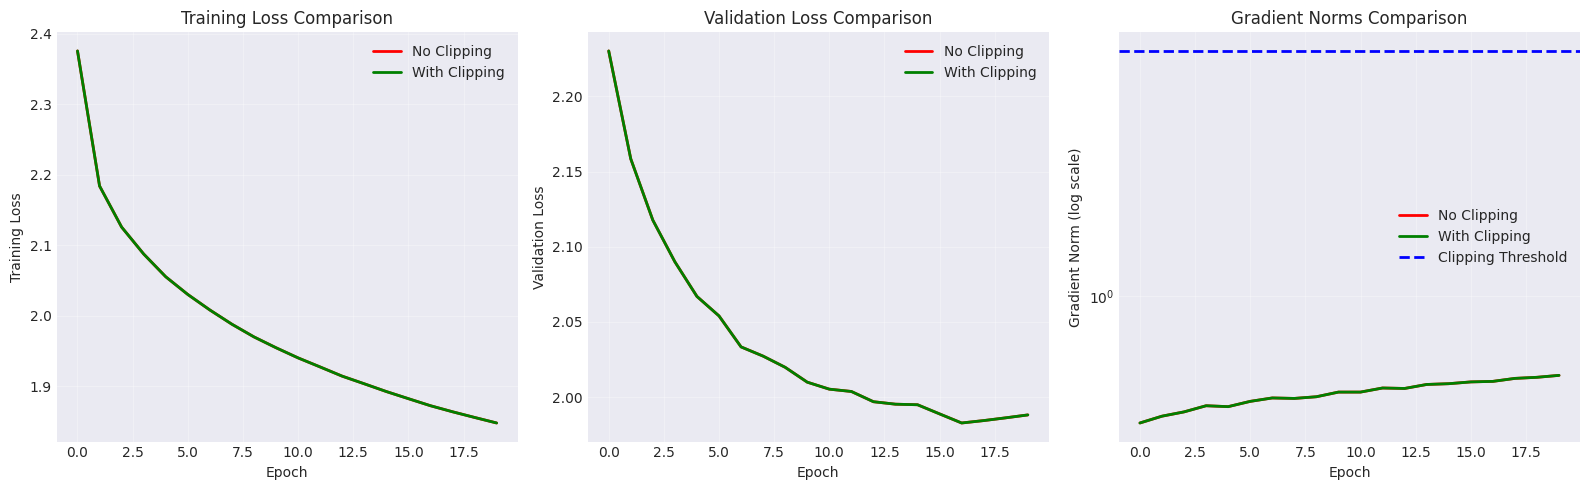


📊 Final Results:

Without Clipping:
   Validation Loss: 1.9882
   Max Grad Norm: 0.59

With Clipping (max_norm=5.0):
   Validation Loss: 1.9882
   Max Grad Norm: 0.59

✨ Improvement: 0.0% reduction in validation loss!


In [18]:
# Compare results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Training loss
axes[0].plot(history_rnn_no_clip['train_loss'], 'r-', linewidth=2, label='No Clipping')
axes[0].plot(history_rnn_with_clip['train_loss'], 'g-', linewidth=2, label='With Clipping')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
axes[1].plot(history_rnn_no_clip['val_loss'], 'r-', linewidth=2, label='No Clipping')
axes[1].plot(history_rnn_with_clip['val_loss'], 'g-', linewidth=2, label='With Clipping')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gradient norms
axes[2].semilogy(history_rnn_no_clip['grad_norm'], 'r-', linewidth=2, label='No Clipping')
axes[2].semilogy(history_rnn_with_clip['grad_norm'], 'g-', linewidth=2, label='With Clipping')
axes[2].axhline(y=5.0, color='blue', linestyle='--', linewidth=2, label='Clipping Threshold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Gradient Norm (log scale)')
axes[2].set_title('Gradient Norms Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Final Results:")
print(f"\nWithout Clipping:")
print(f"   Validation Loss: {history_rnn_no_clip['val_loss'][-1]:.4f}")
print(f"   Max Grad Norm: {max(history_rnn_no_clip['grad_norm']):.2f}")

print(f"\nWith Clipping (max_norm=5.0):")
print(f"   Validation Loss: {history_rnn_with_clip['val_loss'][-1]:.4f}")
print(f"   Max Grad Norm: {max(history_rnn_with_clip['grad_norm']):.2f}")

improvement = (history_rnn_no_clip['val_loss'][-1] - history_rnn_with_clip['val_loss'][-1]) / history_rnn_no_clip['val_loss'][-1] * 100
print(f"\n✨ Improvement: {improvement:.1f}% reduction in validation loss!")

## Part 10: Pros and Cons of Gradient Clipping

### ✅ Advantages (Pros)

1. **Stabilizes Training**
   - Prevents gradient explosion
   - Makes training more robust
   - Allows training of very deep networks

2. **Enables Larger Learning Rates**
   - Can use more aggressive learning rates
   - Faster convergence when appropriate

3. **Simple and Effective**
   - Easy to implement
   - One hyperparameter to tune
   - Works across many architectures

4. **Well-Established**
   - Standard in RNNs, LSTMs, Transformers
   - Proven track record

### ⚠️ Disadvantages (Cons)

1. **Adds Hyperparameter**
   - Need to tune `max_norm`
   - Optimal value varies by problem

2. **Can Slow Convergence**
   - Over-aggressive clipping slows learning
   - May need more epochs to converge

3. **Masks Underlying Issues**
   - Treats symptom, not cause
   - May hide architectural problems
   - Better to fix root cause when possible

4. **May Not Always Help**
   - Shallow networks may not need it
   - Can interfere with some optimizers
   - Not a silver bullet

## Part 11: When to Use Gradient Clipping - Decision Guide

### ✅ USE Gradient Clipping When:

1. **Training RNNs/LSTMs/GRUs**
   - These are particularly prone to gradient explosion
   - Standard practice in sequence modeling
   - Recommended: `max_norm=1.0` to `5.0`

2. **Training Very Deep Networks**
   - Networks with 10+ layers
   - Especially without residual connections
   - Recommended: `max_norm=1.0`

3. **Training Transformers**
   - Common in modern NLP models
   - Helps with training stability
   - Recommended: `max_norm=1.0` to `5.0`

4. **Observing Training Instability**
   - NaN/Inf losses
   - Wildly fluctuating loss curves
   - Diverging gradients

5. **Using High Learning Rates**
   - Want faster convergence
   - Need to prevent explosion from aggressive updates

### ❌ DON'T Use (or Be Cautious) When:

1. **Training Shallow Networks**
   - 3-5 layers usually don't need it
   - Adds unnecessary complexity

2. **Already Using Batch/Layer Normalization**
   - These techniques stabilize gradients
   - May not need additional clipping
   - Try without clipping first

3. **Using Adam/AdaGrad/RMSProp**
   - These optimizers adapt learning rates
   - Already have some gradient stabilization
   - May still help, but less critical

4. **Training is Already Stable**
   - If it ain't broke, don't fix it
   - Monitor gradient norms first

5. **Network Has Residual Connections**
   - ResNets, DenseNets mitigate gradient problems
   - May not need clipping

In [19]:
# Decision flowchart (as code)
def should_use_gradient_clipping(architecture, num_layers, has_normalization, 
                                  has_residual, training_stable):
    """
    Decision helper for gradient clipping.
    
    Returns: (use_clipping: bool, recommended_max_norm: float, reason: str)
    """
    # Strong indicators for clipping
    if architecture in ['RNN', 'LSTM', 'GRU', 'Transformer']:
        return True, 5.0, f"{architecture}s are prone to gradient explosion"
    
    if not training_stable:
        return True, 1.0, "Training is unstable - clipping will help"
    
    if num_layers > 10 and not has_residual:
        return True, 1.0, "Very deep network without residual connections"
    
    # Moderate indicators
    if num_layers > 5 and not has_normalization:
        return True, 1.0, "Deep network without normalization layers"
    
    # Probably don't need it
    if num_layers <= 5 and has_normalization:
        return False, None, "Shallow network with normalization - likely stable"
    
    if has_residual and has_normalization:
        return False, None, "Residual connections + normalization provide stability"
    
    # Default: monitor and decide
    return None, 1.0, "Monitor gradient norms and decide based on training dynamics"

# Test the decision helper
print("🤖 Gradient Clipping Decision Helper\n")

test_cases = [
    ('RNN', 3, False, False, True),
    ('CNN', 20, True, True, True),
    ('CNN', 50, False, False, False),
    ('Transformer', 12, True, False, True),
    ('MLP', 3, True, False, True),
]

for arch, layers, norm, res, stable in test_cases:
    use, max_norm, reason = should_use_gradient_clipping(arch, layers, norm, res, stable)
    
    print(f"Architecture: {arch}, Layers: {layers}, Norm: {norm}, Residual: {res}, Stable: {stable}")
    
    if use is True:
        print(f"  ✅ USE gradient clipping (max_norm={max_norm})")
    elif use is False:
        print(f"  ❌ DON'T use gradient clipping")
    else:
        print(f"  🤔 MONITOR first (suggested max_norm={max_norm})")
    
    print(f"  Reason: {reason}\n")

🤖 Gradient Clipping Decision Helper

Architecture: RNN, Layers: 3, Norm: False, Residual: False, Stable: True
  ✅ USE gradient clipping (max_norm=5.0)
  Reason: RNNs are prone to gradient explosion

Architecture: CNN, Layers: 20, Norm: True, Residual: True, Stable: True
  ❌ DON'T use gradient clipping
  Reason: Residual connections + normalization provide stability

Architecture: CNN, Layers: 50, Norm: False, Residual: False, Stable: False
  ✅ USE gradient clipping (max_norm=1.0)
  Reason: Training is unstable - clipping will help

Architecture: Transformer, Layers: 12, Norm: True, Residual: False, Stable: True
  ✅ USE gradient clipping (max_norm=5.0)
  Reason: Transformers are prone to gradient explosion

Architecture: MLP, Layers: 3, Norm: True, Residual: False, Stable: True
  ❌ DON'T use gradient clipping
  Reason: Shallow network with normalization - likely stable



## Part 12: Monitoring Gradient Norms in Practice

To decide if you need gradient clipping, monitor gradient statistics during training.

In [20]:
def train_with_monitoring(model, train_loader, num_epochs, learning_rate):
    """Train with detailed gradient monitoring."""
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    gradient_stats = {
        'norms': [],
        'max_values': [],
        'min_values': [],
    }
    
    for epoch in range(num_epochs):
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            output, _ = model(batch_x)
            
            output = output.view(-1, tokenizer.vocab_size)
            batch_y = batch_y.view(-1)
            
            loss = F.cross_entropy(output, batch_y)
            loss.backward()
            
            # Collect gradient statistics
            grad_norm = compute_gradient_norm(model)
            max_grad = max(p.grad.abs().max().item() for p in model.parameters() if p.grad is not None)
            min_grad = min(p.grad.abs().min().item() for p in model.parameters() if p.grad is not None)
            
            gradient_stats['norms'].append(grad_norm)
            gradient_stats['max_values'].append(max_grad)
            gradient_stats['min_values'].append(min_grad)
            
            optimizer.step()
    
    return gradient_stats

# Train and monitor
print("Training with gradient monitoring...\n")
set_seed(42)
model_monitor = CharRNN(tokenizer.vocab_size, 32, 128, 3).to(device)
grad_stats = train_with_monitoring(model_monitor, train_loader, num_epochs=5, learning_rate=0.001)

print("✓ Training complete!")

Training with gradient monitoring...



✓ Training complete!


Visualize the results with multiple plots for comparison.

/tmp/ipykernel_56812/875426529.py:64: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


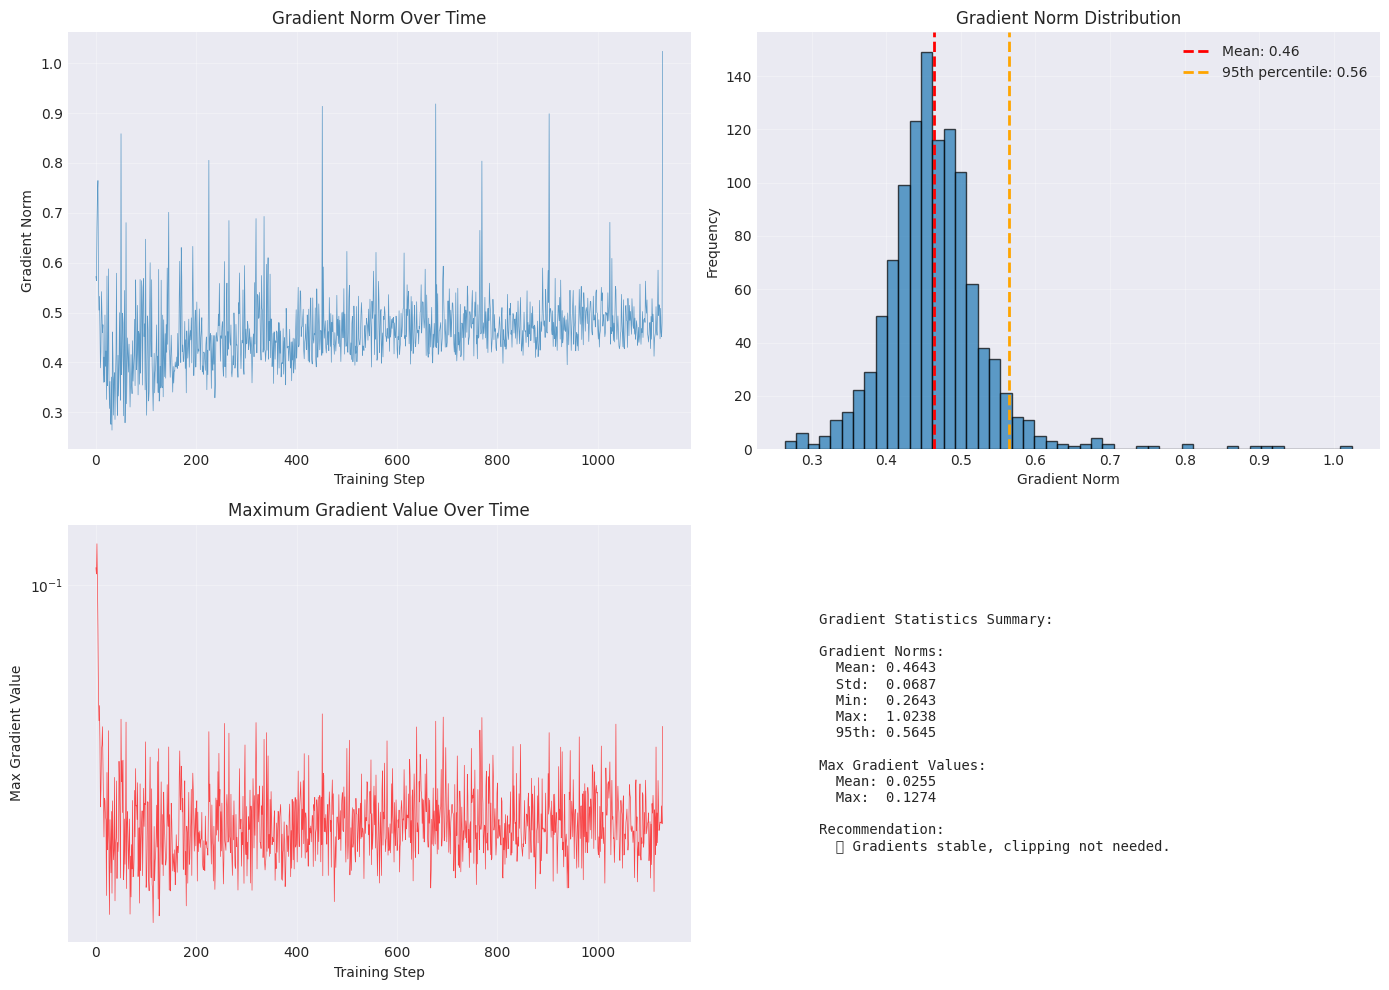

In [21]:
# Analyze gradient statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gradient norms over time
axes[0, 0].plot(grad_stats['norms'], linewidth=0.5, alpha=0.7)
axes[0, 0].set_xlabel('Training Step')
axes[0, 0].set_ylabel('Gradient Norm')
axes[0, 0].set_title('Gradient Norm Over Time')
axes[0, 0].grid(True, alpha=0.3)

# Gradient norm distribution
axes[0, 1].hist(grad_stats['norms'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(np.mean(grad_stats['norms']), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(grad_stats["norms"]):.2f}')
axes[0, 1].axvline(np.percentile(grad_stats['norms'], 95), color='orange', 
                   linestyle='--', linewidth=2, label=f'95th percentile: {np.percentile(grad_stats["norms"], 95):.2f}')
axes[0, 1].set_xlabel('Gradient Norm')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Gradient Norm Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Max gradient values
axes[1, 0].plot(grad_stats['max_values'], linewidth=0.5, alpha=0.7, color='red')
axes[1, 0].set_xlabel('Training Step')
axes[1, 0].set_ylabel('Max Gradient Value')
axes[1, 0].set_title('Maximum Gradient Value Over Time')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Summary statistics
stats_text = f"""Gradient Statistics Summary:

Gradient Norms:
  Mean: {np.mean(grad_stats['norms']):.4f}
  Std:  {np.std(grad_stats['norms']):.4f}
  Min:  {np.min(grad_stats['norms']):.4f}
  Max:  {np.max(grad_stats['norms']):.4f}
  95th: {np.percentile(grad_stats['norms'], 95):.4f}

Max Gradient Values:
  Mean: {np.mean(grad_stats['max_values']):.4f}
  Max:  {np.max(grad_stats['max_values']):.4f}

Recommendation:
"""

# Add recommendation
mean_norm = np.mean(grad_stats['norms'])
max_norm = np.max(grad_stats['norms'])
p95_norm = np.percentile(grad_stats['norms'], 95)

if max_norm > 100:
    stats_text += f"  ✅ USE clipping! Gradients exploding.\n  Suggested max_norm: {p95_norm:.1f}"
elif max_norm > 10:
    stats_text += f"  🤔 Consider clipping for stability.\n  Suggested max_norm: {p95_norm:.1f}"
else:
    stats_text += "  ❌ Gradients stable, clipping not needed."

axes[1, 1].text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
               verticalalignment='center')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### How to Read These Statistics

**Gradient Norm Guidelines:**
- **< 1.0**: Very small gradients (potential vanishing)
- **1.0 - 10.0**: Healthy range for most networks
- **10.0 - 100.0**: Consider gradient clipping
- **> 100.0**: Definitely use gradient clipping!

**Choosing max_norm:**
- Use the 95th percentile of gradient norms as a starting point
- Round to a nice value (e.g., 1.0, 5.0, 10.0)
- Fine-tune based on training performance

## Part 13: Advanced Topics and Variants

### 1. Adaptive Gradient Clipping (AGC)

A newer technique that clips gradients relative to parameter norms:

$$\text{clip\_factor} = \min\left(1, \frac{\lambda \cdot \|\mathbf{w}\|}{\|\mathbf{g}\|}\right)$$

where $\mathbf{w}$ are parameters, $\mathbf{g}$ are gradients, and $\lambda$ is a clipping parameter.

**Benefits:**
- Adapts to parameter scales
- May work better for large models
- Used in some modern architectures (NFNets)

In [22]:
def adaptive_gradient_clipping(parameters, clip_factor=0.01):
    """Implement adaptive gradient clipping."""
    for p in parameters:
        if p.grad is not None:
            param_norm = p.data.norm(2)
            grad_norm = p.grad.data.norm(2)
            
            max_norm = clip_factor * param_norm
            clip_coef = max_norm / (grad_norm + 1e-6)
            
            if clip_coef < 1.0:
                p.grad.data.mul_(clip_coef)

print("✓ Adaptive gradient clipping implemented")
print("\nNote: AGC is more advanced and typically used in specific scenarios.")
print("For most cases, standard gradient clipping is sufficient and well-tested.")

✓ Adaptive gradient clipping implemented

Note: AGC is more advanced and typically used in specific scenarios.
For most cases, standard gradient clipping is sufficient and well-tested.


### 2. Gradient Clipping + Mixed Precision Training

When using mixed precision (fp16), gradient clipping is even more important:
- fp16 has limited range (~65,000)
- More prone to overflow
- Clipping prevents fp16 overflow

**Best Practice**: Always use gradient clipping with mixed precision!

### 3. Relationship with Learning Rate Schedules

Gradient clipping interacts with learning rate schedules:

- **Warmup**: Clipping is less critical during warmup (small LR)
- **Peak LR**: Most important during high learning rate phase
- **Decay**: Less critical as LR decreases

Consider adjusting `max_norm` along with learning rate schedule for optimal results.

## Part 14: Practical Checklist - Quick Reference

### Before Training

- [ ] Identify your architecture (RNN/CNN/Transformer/etc.)
- [ ] Count network depth (number of layers)
- [ ] Check for normalization layers (BatchNorm/LayerNorm)
- [ ] Check for residual connections
- [ ] Decide on initial `max_norm` value

### During Training

- [ ] Monitor gradient norms (log them!)
- [ ] Watch for NaN/Inf losses
- [ ] Check if clipping is activating (compare pre/post clip norms)
- [ ] Observe training stability

### Troubleshooting

**If training is unstable:**
- [ ] Add gradient clipping if not using
- [ ] Decrease `max_norm` if already clipping
- [ ] Consider reducing learning rate
- [ ] Check data preprocessing

**If training is too slow:**
- [ ] Increase `max_norm` if clipping too aggressively
- [ ] Try removing clipping if gradients are stable
- [ ] Consider increasing learning rate (with clipping)

**If you see NaN losses:**
- [ ] Immediately add gradient clipping
- [ ] Start with `max_norm=1.0`
- [ ] Reduce learning rate
- [ ] Check for numerical instabilities in your code

## Part 15: Final Experiment - Putting It All Together

Let's do one final comprehensive experiment comparing different configurations.

In [23]:
# Final comprehensive comparison
configs = [
    {'name': 'Baseline (no clip)', 'lr': 0.001, 'clip': None},
    {'name': 'Conservative clip', 'lr': 0.001, 'clip': 1.0},
    {'name': 'Moderate clip', 'lr': 0.001, 'clip': 5.0},
    {'name': 'Aggressive LR + clip', 'lr': 0.003, 'clip': 5.0},
]

final_results = {}

print("Running final comprehensive comparison...\n")

for config in configs:
    print(f"Training: {config['name']}...")
    set_seed(42)
    
    model = CharRNN(tokenizer.vocab_size, 32, 128, 3).to(device)
    history = train_rnn(model, train_loader, val_loader, 
                       num_epochs=20, 
                       learning_rate=config['lr'],
                       clip_value=config['clip'])
    
    final_results[config['name']] = history
    print()

print("✓ All experiments complete!")

Running final comprehensive comparison...

Training: Baseline (no clip)...


Epoch  0 | Train Loss: 2.3759 | Val Loss: 2.2302 | Grad Norm: 0.43


Epoch  5 | Train Loss: 2.0301 | Val Loss: 2.0540 | Grad Norm: 0.50


Epoch 10 | Train Loss: 1.9401 | Val Loss: 2.0053 | Grad Norm: 0.53


Epoch 15 | Train Loss: 1.8822 | Val Loss: 1.9888 | Grad Norm: 0.57


...

Epoch  0 | Train Loss: 2.3006 | Val Loss: 2.1739 | Grad Norm: 0.46


Epoch  5 | Train Loss: 1.9806 | Val Loss: 2.0219 | Grad Norm: 0.45


Epoch 10 | Train Loss: 1.9067 | Val Loss: 2.0004 | Grad Norm: 0.47


Epoch 15 | Train Loss: 1.8642 | Val Loss: 2.0004 | Grad Norm: 0.48


Epoch 19 | Train Loss: 1.8436 | Val Loss: 2.0086 | Grad Norm: 0.50

✓ All experiments complete!


Visualize the results with multiple plots for comparison.

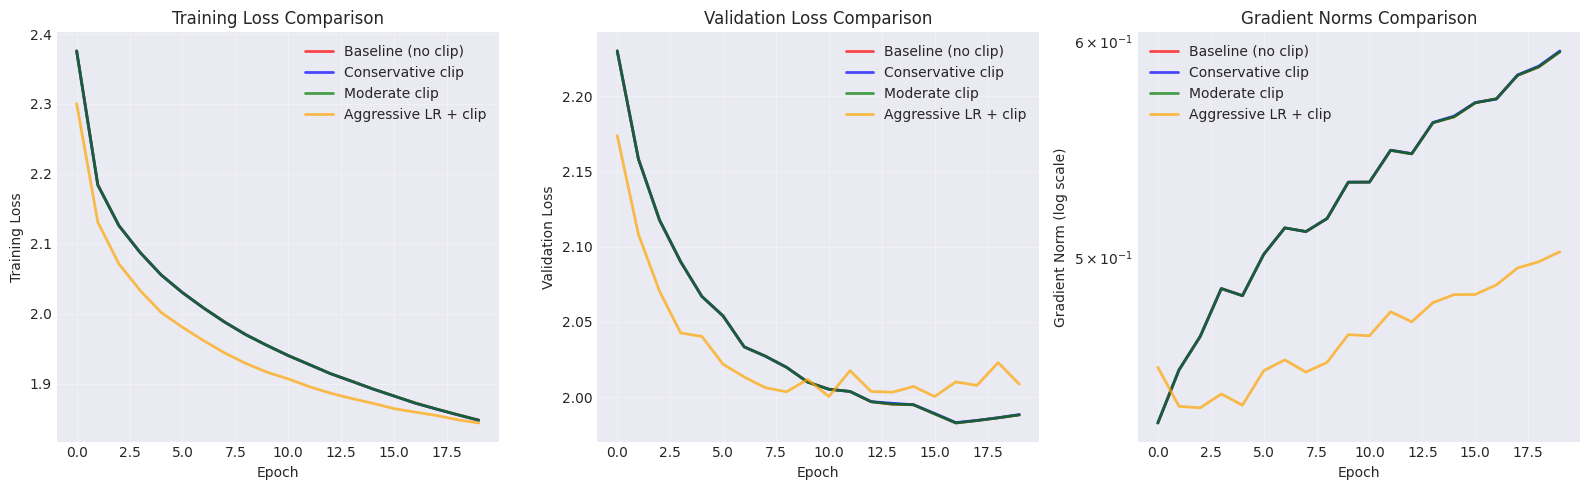


FINAL PERFORMANCE SUMMARY

Configuration             Val Loss     Max Grad     Stable?
--------------------------------------------------------------------------------
Baseline (no clip)        1.9882       0.59         ✓
Conservative clip         1.9884       0.59         ✓
Moderate clip             1.9882       0.59         ✓
Aggressive LR + clip      2.0086       0.50         ✓

🏆 BEST CONFIGURATION: Baseline (no clip)
   Final Validation Loss: 1.9882


In [24]:
# Final visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['red', 'blue', 'green', 'orange']

# Training loss
for (name, history), color in zip(final_results.items(), colors):
    axes[0].plot(history['train_loss'], linewidth=2, label=name, color=color, alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
for (name, history), color in zip(final_results.items(), colors):
    axes[1].plot(history['val_loss'], linewidth=2, label=name, color=color, alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gradient norms
for (name, history), color in zip(final_results.items(), colors):
    axes[2].semilogy(history['grad_norm'], linewidth=2, label=name, color=color, alpha=0.7)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Gradient Norm (log scale)')
axes[2].set_title('Gradient Norms Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final summary table
print("\n" + "="*80)
print("FINAL PERFORMANCE SUMMARY")
print("="*80)
print(f"\n{'Configuration':<25} {'Val Loss':<12} {'Max Grad':<12} {'Stable?'}")
print("-" * 80)

for name, history in final_results.items():
    val_loss = history['val_loss'][-1]
    max_grad = max(history['grad_norm'])
    stable = "✓" if max_grad < 50 and not any(np.isnan(history['val_loss'])) else "✗"
    print(f"{name:<25} {val_loss:<12.4f} {max_grad:<12.2f} {stable}")

# Find best configuration
best_config = min(final_results.items(), key=lambda x: x[1]['val_loss'][-1])
print("\n" + "="*80)
print(f"🏆 BEST CONFIGURATION: {best_config[0]}")
print(f"   Final Validation Loss: {best_config[1]['val_loss'][-1]:.4f}")
print("="*80)

## Part 16: Key Takeaways & Summary

### 🎯 Core Concepts

1. **Gradient Problems**: Deep networks suffer from exploding/vanishing gradients due to multiplicative effects through layers

2. **Gradient Clipping**: Limits gradient magnitude while preserving direction
   - Formula: $\mathbf{g}_{\text{clip}} = \mathbf{g} \cdot \min\left(1, \frac{\text{max\_norm}}{\|\mathbf{g}\|}\right)$

3. **When to Use**: RNNs, very deep networks, transformers, unstable training

4. **When Not to Use**: Shallow networks, already normalized/stabilized networks

### 🛠️ Practical Guidelines

1. **Default `max_norm` values**:
   - RNNs/LSTMs: 1.0 - 5.0
   - Transformers: 1.0 - 5.0  
   - Deep CNNs: 1.0
   - General: Start with 1.0

2. **Monitoring**: Always log gradient norms during training

3. **Tuning**: Use 95th percentile of gradient norms as starting point

4. **PyTorch**: `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)`

### 💡 Final Insights

- Gradient clipping is a **symptom treatment**, not a cure
- Better architectures (ResNets, normalization) reduce need for clipping
- But for RNNs and very deep networks, it's **essential**
- Always **monitor first**, then **apply intelligently**
- One of the **simplest** yet **most effective** stabilization techniques

### 🎓 Reflection Questions

1. Why does gradient clipping preserve gradient direction?
2. What's the relationship between network depth and gradient magnitude?
3. How do residual connections help with gradient flow?
4. When might gradient clipping actually harm training?
5. How would you choose `max_norm` for a new architecture?

---

**Congratulations!** 🎉 You now have strong intuitions about gradient normalization, when to use it, and how to apply it effectively in your deep learning projects.

## Further Exploration

Want to dive deeper? Try these experiments:

1. **Implement adaptive gradient clipping** and compare with standard clipping
2. **Visualize per-layer gradients** to see where explosion/vanishing occurs
3. **Test on different architectures** (CNNs, ResNets, attention mechanisms)
4. **Combine with other techniques** (layer normalization, residual connections)
5. **Study gradient flow** in transformers with multi-head attention
6. **Experiment with gradient accumulation** and clipping

Happy learning! 🚀